In [1]:
!pip install -q open_clip_torch

from google.colab import drive
drive.mount("/content/drive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/ATML/PA1")
TASK1_ROOT = PROJECT_ROOT / "task1"

SPLITS_DIR = TASK1_ROOT / "splits"
FEATURES_DIR = TASK1_ROOT / "cached_features"
RESULTS_DIR = TASK1_ROOT / "results"
FIGURES_DIR = TASK1_ROOT / "figures"
CUE_ROOT = TASK1_ROOT / "data" / "cue_conflicts"

SEED = 6304
NUM_CLASSES = 10

CLASS_NAMES = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck",
]

MODEL_NAMES = [
    "resnet50",
    "vit_b_16",
    "clip_vit_b_32",
]

MODEL_DISPLAY_NAMES = {
    "resnet50": "ResNet-50",
    "vit_b_16": "ViT-B/16",
    "clip_vit_b_32": "CLIP ViT-B/32",
}

In [4]:
def set_seed(seed=6304):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(SEED)

In [5]:
def load_features(file_name):
    path = FEATURES_DIR / file_name

    if not path.exists():
        raise FileNotFoundError(
            f"Missing feature file: {path}"
        )

    return torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

In [6]:
def cosine_stability(
    clean_features,
    transformed_features,
):
    assert clean_features.shape == (
        transformed_features.shape
    )

    individual_similarities = (
        F.cosine_similarity(
            clean_features.float(),
            transformed_features.float(),
            dim=1,
        )
    )

    return {
        "mean": individual_similarities.mean().item(),
        "std": individual_similarities.std().item(),
        "values": individual_similarities,
    }

In [7]:
stability_rows = []
per_image_stability_rows = []

DIRECT_INTERVENTIONS = {
    "grayscale": "grayscale",
    "patch_shuffle": "patch_shuffle_4x4",
}

for model_name in MODEL_NAMES:
    clean_data = load_features(
        f"{model_name}_clean_test.pt"
    )

    for display_condition, file_condition in (
        DIRECT_INTERVENTIONS.items()
    ):
        transformed_data = load_features(
            f"{model_name}_{file_condition}_test.pt"
        )

        assert torch.equal(
            clean_data["indices"],
            transformed_data["indices"],
        )

        stability = cosine_stability(
            clean_data["features"],
            transformed_data["features"],
        )

        stability_rows.append({
            "model": model_name,
            "intervention": display_condition,
            "mean_cosine_stability": stability["mean"],
            "std_cosine_stability": stability["std"],
            "number_of_pairs": len(
                stability["values"]
            ),
        })

        for index, value in zip(
            clean_data["indices"].tolist(),
            stability["values"].tolist(),
        ):
            per_image_stability_rows.append({
                "model": model_name,
                "intervention": display_condition,
                "image_identifier": index,
                "cosine_stability": value,
            })

In [8]:
TRANSLATION_DISPLACEMENTS = [0, 8, 16, 32]

TRANSLATION_DIRECTIONS = [
    "up",
    "down",
    "left",
    "right",
]

translation_stability_rows = []

for model_name in MODEL_NAMES:
    clean_data = load_features(
        f"{model_name}_clean_test.pt"
    )

    for displacement in TRANSLATION_DISPLACEMENTS:
        for direction in TRANSLATION_DIRECTIONS:

            if displacement == 0:
                transformed_data = clean_data

            else:
                transformed_data = load_features(
                    f"{model_name}_translation_"
                    f"{direction}_{displacement}px_test.pt"
                )

            assert torch.equal(
                clean_data["indices"],
                transformed_data["indices"],
            )

            stability = cosine_stability(
                clean_data["features"],
                transformed_data["features"],
            )

            translation_stability_rows.append({
                "model": model_name,
                "displacement": displacement,
                "direction": direction,
                "mean_cosine_stability": stability["mean"],
                "std_cosine_stability": stability["std"],
                "number_of_pairs": len(
                    stability["values"]
                ),
            })

In [9]:
translation_stability_directional_df = (
    pd.DataFrame(
        translation_stability_rows
    )
)

translation_stability_average_df = (
    translation_stability_directional_df
    .groupby(
        ["model", "displacement"],
        as_index=False,
    )
    .agg(
        mean_cosine_stability=(
            "mean_cosine_stability",
            "mean",
        ),
        direction_variation=(
            "mean_cosine_stability",
            "std",
        ),
    )
)

translation_stability_directional_df.to_csv(
    RESULTS_DIR
    / "translation_representation_stability_directional.csv",
    index=False,
)

translation_stability_average_df.to_csv(
    RESULTS_DIR
    / "translation_representation_stability_average.csv",
    index=False,
)

display(
    translation_stability_average_df.round(4)
)

,model,displacement,mean_cosine_stability,direction_variation
0,clip_vit_b_32,0,1.0000,0.0000
1,clip_vit_b_32,8,0.9810,0.0002
2,clip_vit_b_32,16,0.9680,0.0034
3,clip_vit_b_32,32,0.9699,0.0059
4,resnet50,0,1.0000,0.0000
5,resnet50,8,0.9685,0.0039
6,resnet50,16,0.9525,0.0074
7,resnet50,32,0.9327,0.0090
8,vit_b_16,0,1.0000,0.0000
9,vit_b_16,8,0.9471,0.0028


In [10]:
translation_32 = (
    translation_stability_average_df[
        translation_stability_average_df[
            "displacement"
        ] == 32
    ]
)

for row in translation_32.itertuples(index=False):
    stability_rows.append({
        "model": row.model,
        "intervention": "translation_32px",
        "mean_cosine_stability": (
            row.mean_cosine_stability
        ),
        "std_cosine_stability": (
            row.direction_variation
        ),
        "number_of_pairs": 500,
    })

In [11]:
selected_conflicts = pd.read_csv(
    CUE_ROOT / "selected_conflicts_200.csv"
)

print("Cue conflicts:", len(selected_conflicts))

display(
    selected_conflicts[
        [
            "candidate_id",
            "content_index",
            "content_class",
            "style_class",
        ]
    ].head()
)

Cue conflicts: 200


,candidate_id,content_index,content_class,style_class
0,pair0_airplane_to_bird_05,5117,airplane,bird
1,pair0_airplane_to_bird_06,7262,airplane,bird
2,pair0_airplane_to_bird_09,7150,airplane,bird
3,pair0_airplane_to_bird_10,5918,airplane,bird
4,pair0_airplane_to_bird_11,1648,airplane,bird


In [12]:
def get_clean_content_features(
    clean_data,
    selected_metadata,
):
    clean_index_to_position = {
        int(image_index): position
        for position, image_index
        in enumerate(
            clean_data["indices"].tolist()
        )
    }

    clean_positions = []

    for content_index in selected_metadata[
        "content_index"
    ]:
        content_index = int(content_index)

        if content_index not in (
            clean_index_to_position
        ):
            raise ValueError(
                f"Content index {content_index} "
                "is missing from clean features."
            )

        clean_positions.append(
            clean_index_to_position[
                content_index
            ]
        )

    return clean_data["features"][
        clean_positions
    ]

In [13]:
for model_name in MODEL_NAMES:
    clean_data = load_features(
        f"{model_name}_clean_test.pt"
    )

    conflict_data = load_features(
        f"{model_name}_cue_conflicts_200.pt"
    )

    clean_content_features = (
        get_clean_content_features(
            clean_data,
            selected_conflicts,
        )
    )

    assert clean_content_features.shape == (
        conflict_data["features"].shape
    )

    assert (
        conflict_data["candidate_ids"]
        == selected_conflicts[
            "candidate_id"
        ].tolist()
    )

    stability = cosine_stability(
        clean_content_features,
        conflict_data["features"],
    )

    stability_rows.append({
        "model": model_name,
        "intervention": "cue_conflict",
        "mean_cosine_stability": stability["mean"],
        "std_cosine_stability": stability["std"],
        "number_of_pairs": 200,
    })

    for candidate_id, value in zip(
        selected_conflicts[
            "candidate_id"
        ],
        stability["values"].tolist(),
    ):
        per_image_stability_rows.append({
            "model": model_name,
            "intervention": "cue_conflict",
            "image_identifier": candidate_id,
            "cosine_stability": value,
        })

In [14]:
representation_stability_df = (
    pd.DataFrame(stability_rows)
)

representation_stability_df[
    "model_display"
] = representation_stability_df[
    "model"
].map(MODEL_DISPLAY_NAMES)

representation_stability_df.to_csv(
    RESULTS_DIR
    / "representation_stability_summary.csv",
    index=False,
)

per_image_stability_df = pd.DataFrame(
    per_image_stability_rows
)

per_image_stability_df.to_csv(
    RESULTS_DIR
    / "representation_stability_per_image.csv",
    index=False,
)

display(
    representation_stability_df[
        [
            "model_display",
            "intervention",
            "mean_cosine_stability",
            "std_cosine_stability",
            "number_of_pairs",
        ]
    ].round(4)
)

,model_display,intervention,mean_cosine_stability,std_cosine_stability,number_of_pairs
0,ResNet-50,grayscale,0.7884,0.0979,500
1,ResNet-50,patch_shuffle,0.7178,0.0747,500
2,ViT-B/16,grayscale,0.7393,0.1262,500
3,ViT-B/16,patch_shuffle,0.6534,0.1103,500
4,CLIP ViT-B/32,grayscale,0.8983,0.0397,500
5,CLIP ViT-B/32,patch_shuffle,0.7290,0.0642,500
6,CLIP ViT-B/32,translation_32px,0.9699,0.0059,500
7,ResNet-50,translation_32px,0.9327,0.0090,500
8,ViT-B/16,translation_32px,0.9418,0.0076,500
9,ResNet-50,cue_conflict,0.3544,0.1587,200


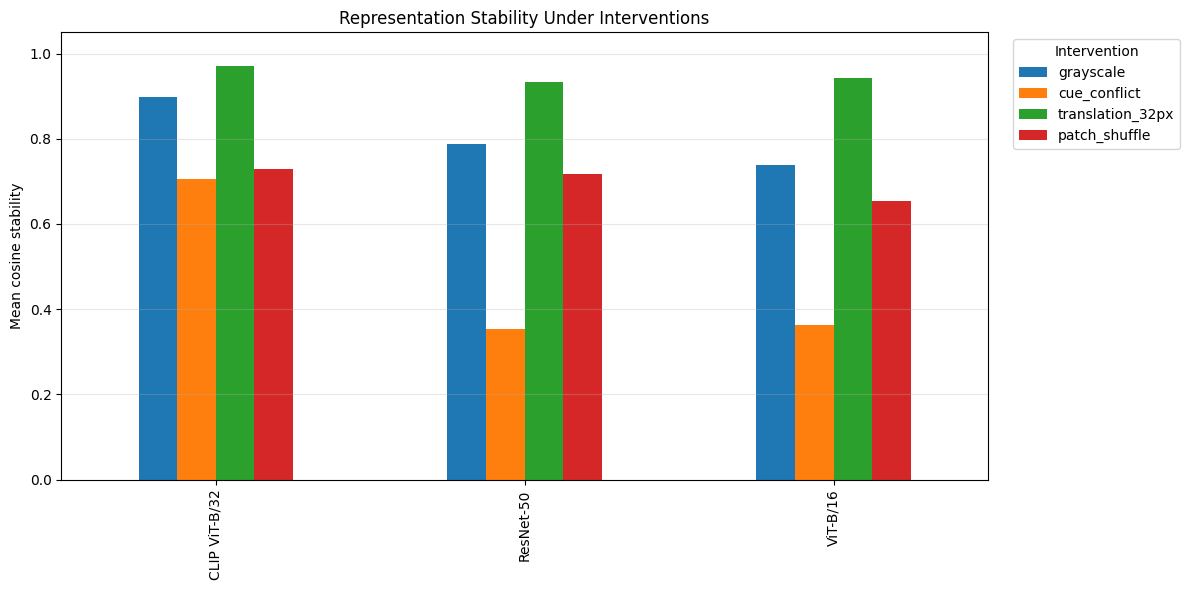

In [15]:
intervention_order = [
    "grayscale",
    "cue_conflict",
    "translation_32px",
    "patch_shuffle",
]

stability_pivot = (
    representation_stability_df
    .pivot(
        index="model_display",
        columns="intervention",
        values="mean_cosine_stability",
    )
    [intervention_order]
)

stability_pivot.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.ylabel("Mean cosine stability")
plt.xlabel("")
plt.title(
    "Representation Stability Under Interventions"
)

plt.ylim(0, 1.05)
plt.grid(
    axis="y",
    alpha=0.3,
)

plt.legend(
    title="Intervention",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "representation_stability_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

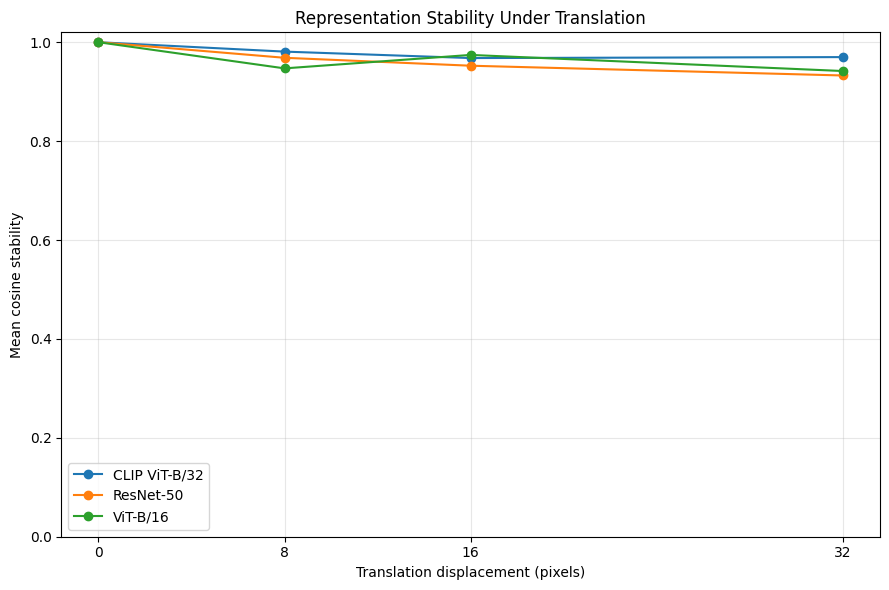

In [16]:
plt.figure(figsize=(9, 6))

for model_name, group in (
    translation_stability_average_df
    .groupby("model")
):
    group = group.sort_values(
        "displacement"
    )

    plt.plot(
        group["displacement"],
        group["mean_cosine_stability"],
        marker="o",
        label=MODEL_DISPLAY_NAMES[
            model_name
        ],
    )

plt.xlabel("Translation displacement (pixels)")
plt.ylabel("Mean cosine stability")
plt.title(
    "Representation Stability Under Translation"
)

plt.xticks(
    TRANSLATION_DISPLACEMENTS
)

plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "translation_representation_stability.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [17]:
VISUALIZATION_SUBSET_PATH = (
    SPLITS_DIR
    / "representation_visualization_200_seed6304.json"
)

reference_clean_data = load_features(
    "resnet50_clean_test.pt"
)

reference_indices = (
    reference_clean_data["indices"].numpy()
)

reference_labels = (
    reference_clean_data["labels"].numpy()
)

if VISUALIZATION_SUBSET_PATH.exists():
    with open(
        VISUALIZATION_SUBSET_PATH,
        "r",
    ) as file:
        visualization_information = (
            json.load(file)
        )

    visualization_indices = np.array(
        visualization_information[
            "image_indices"
        ]
    )

else:
    rng = np.random.default_rng(SEED)
    visualization_indices = []

    for class_id in range(NUM_CLASSES):
        class_positions = np.where(
            reference_labels == class_id
        )[0]

        chosen_positions = rng.choice(
            class_positions,
            size=20,
            replace=False,
        )

        chosen_identifiers = (
            reference_indices[
                chosen_positions
            ]
        )

        visualization_indices.extend(
            chosen_identifiers.tolist()
        )

    visualization_indices = np.array(
        visualization_indices
    )

    rng.shuffle(visualization_indices)

    with open(
        VISUALIZATION_SUBSET_PATH,
        "w",
    ) as file:
        json.dump(
            {
                "seed": SEED,
                "images_per_class": 20,
                "image_indices": (
                    visualization_indices.tolist()
                ),
            },
            file,
            indent=2,
        )

print(
    "Visualization images:",
    len(visualization_indices),
)

Visualization images: 200


In [18]:
def select_features_by_identifier(
    feature_data,
    identifiers,
):
    index_to_position = {
        int(image_index): position
        for position, image_index
        in enumerate(
            feature_data["indices"].tolist()
        )
    }

    positions = [
        index_to_position[int(identifier)]
        for identifier in identifiers
    ]

    return (
        feature_data["features"][positions],
        feature_data["labels"][positions],
    )

In [19]:
def joint_tsne_projection(
    clean_features,
    transformed_features,
):
    clean_array = (
        clean_features.float().numpy()
    )

    transformed_array = (
        transformed_features.float().numpy()
    )

    combined_features = np.concatenate(
        [
            clean_array,
            transformed_array,
        ],
        axis=0,
    )

    number_of_pca_components = min(
        50,
        combined_features.shape[1],
        combined_features.shape[0] - 1,
    )

    pca = PCA(
        n_components=number_of_pca_components,
        random_state=SEED,
    )

    reduced_features = pca.fit_transform(
        combined_features
    )

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=SEED,
    )

    projected_features = tsne.fit_transform(
        reduced_features
    )

    number_of_images = len(
        clean_features
    )

    return {
        "clean": projected_features[
            :number_of_images
        ],
        "transformed": projected_features[
            number_of_images:
        ],
        "pca_variance": (
            pca.explained_variance_ratio_.sum()
        ),
    }

In [20]:
def get_visualization_pair(
    model_name,
    intervention,
):
    clean_data = load_features(
        f"{model_name}_clean_test.pt"
    )

    if intervention == "cue_conflict":
        conflict_data = load_features(
            f"{model_name}_cue_conflicts_200.pt"
        )

        clean_features = (
            get_clean_content_features(
                clean_data,
                selected_conflicts,
            )
        )

        transformed_features = (
            conflict_data["features"]
        )

        labels = torch.tensor(
            selected_conflicts[
                "content_label"
            ].to_numpy(),
            dtype=torch.long,
        )

        return (
            clean_features,
            transformed_features,
            labels,
        )

    clean_features, labels = (
        select_features_by_identifier(
            clean_data,
            visualization_indices,
        )
    )

    if intervention == "grayscale":
        transformed_data = load_features(
            f"{model_name}_grayscale_test.pt"
        )

    elif intervention == "patch_shuffle":
        transformed_data = load_features(
            f"{model_name}_patch_shuffle_4x4_test.pt"
        )

    elif intervention == "translation_32px_right":
        transformed_data = load_features(
            f"{model_name}_translation_right_32px_test.pt"
        )

    else:
        raise ValueError(
            f"Unknown intervention: {intervention}"
        )

    transformed_features, transformed_labels = (
        select_features_by_identifier(
            transformed_data,
            visualization_indices,
        )
    )

    assert torch.equal(
        labels,
        transformed_labels,
    )

    return (
        clean_features,
        transformed_features,
        labels,
    )

In [21]:
CLASS_COLORS = plt.cm.tab10(
    np.linspace(0, 1, NUM_CLASSES)
)


def plot_projection(
    axis,
    projection,
    labels,
    title,
):
    labels = np.asarray(labels)

    clean_projection = projection["clean"]
    transformed_projection = (
        projection["transformed"]
    )

    for class_id in range(NUM_CLASSES):
        class_mask = labels == class_id

        axis.scatter(
            clean_projection[
                class_mask, 0
            ],
            clean_projection[
                class_mask, 1
            ],
            color=CLASS_COLORS[class_id],
            marker="o",
            s=20,
            alpha=0.45,
        )

        axis.scatter(
            transformed_projection[
                class_mask, 0
            ],
            transformed_projection[
                class_mask, 1
            ],
            color=CLASS_COLORS[class_id],
            marker="x",
            s=24,
            alpha=0.8,
        )

    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])

Creating projections for: Grayscale


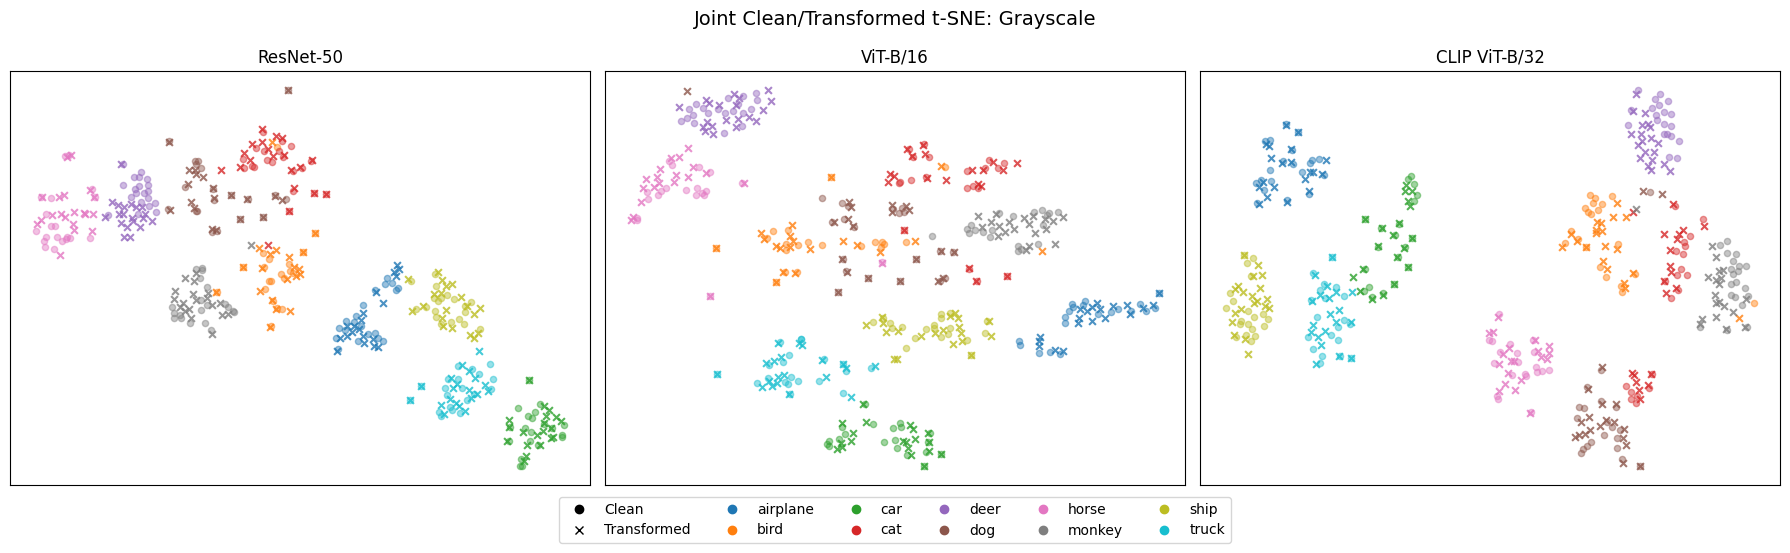

Creating projections for: Cue Conflict


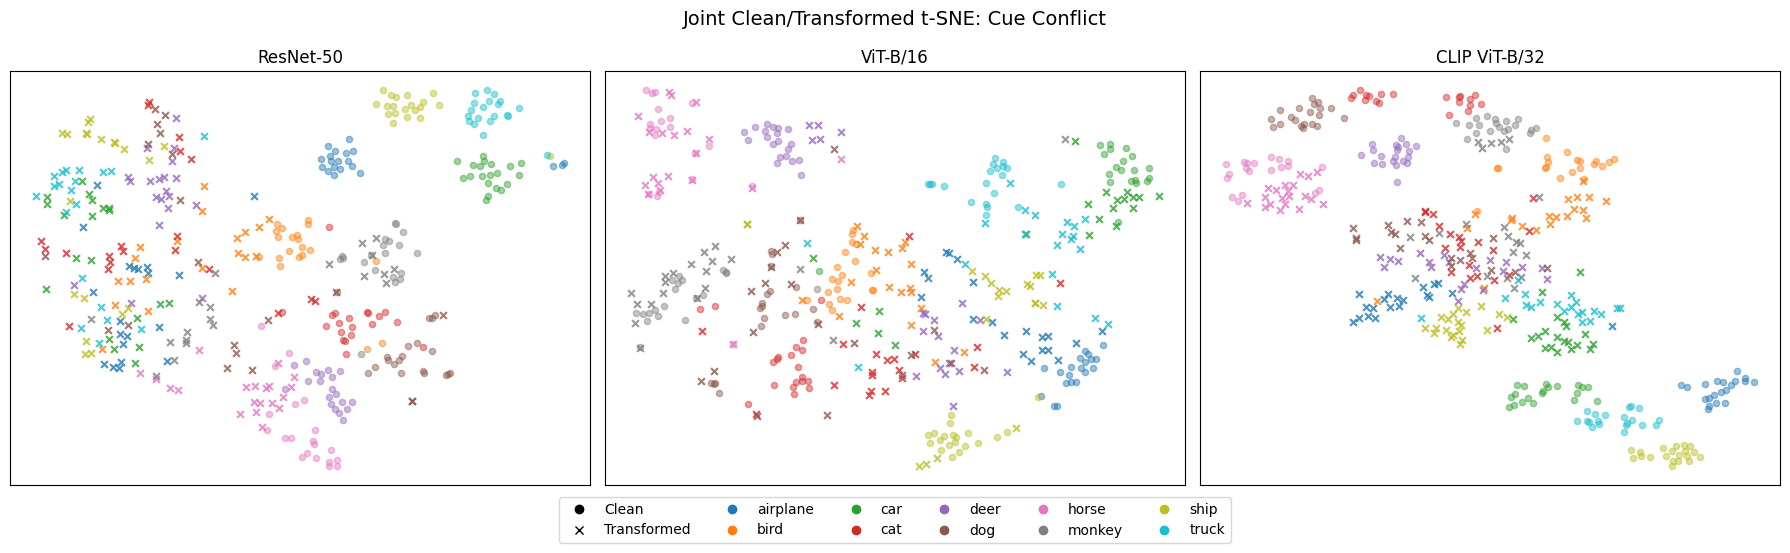

Creating projections for: Translation: 32 px Right


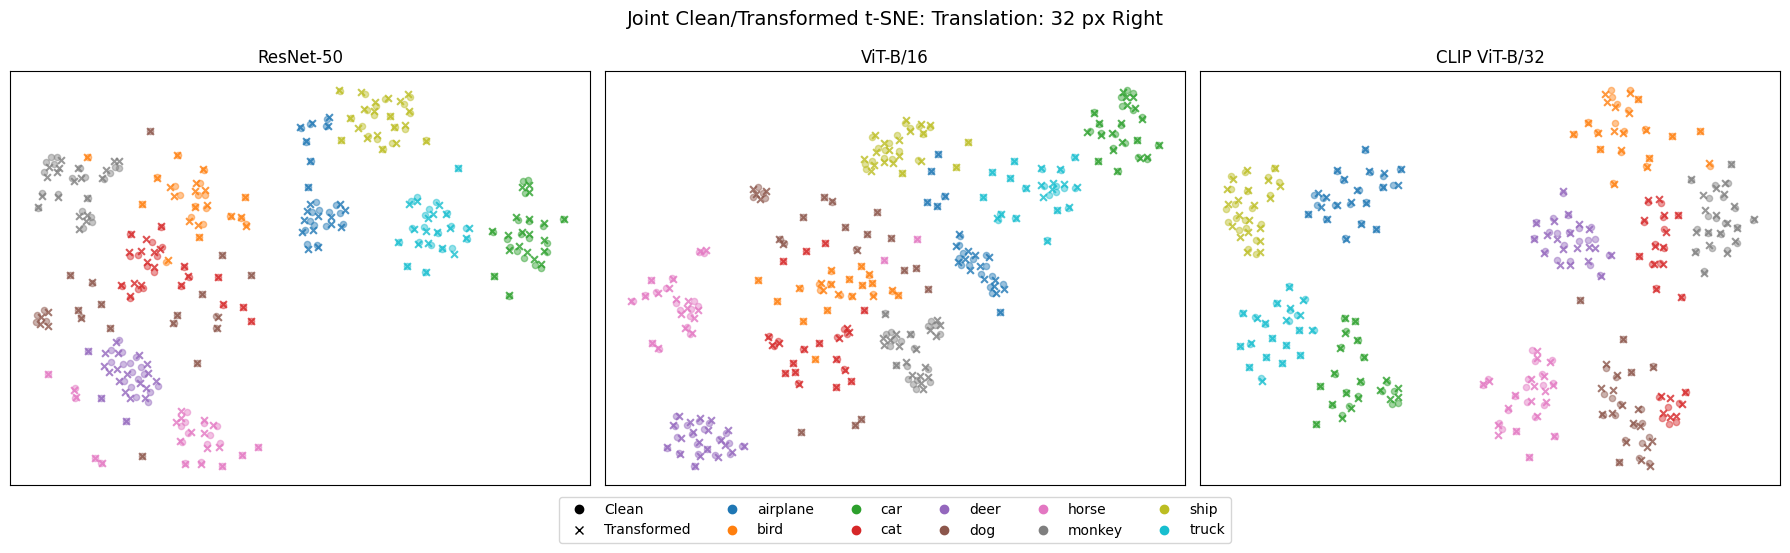

Creating projections for: Patch Shuffle


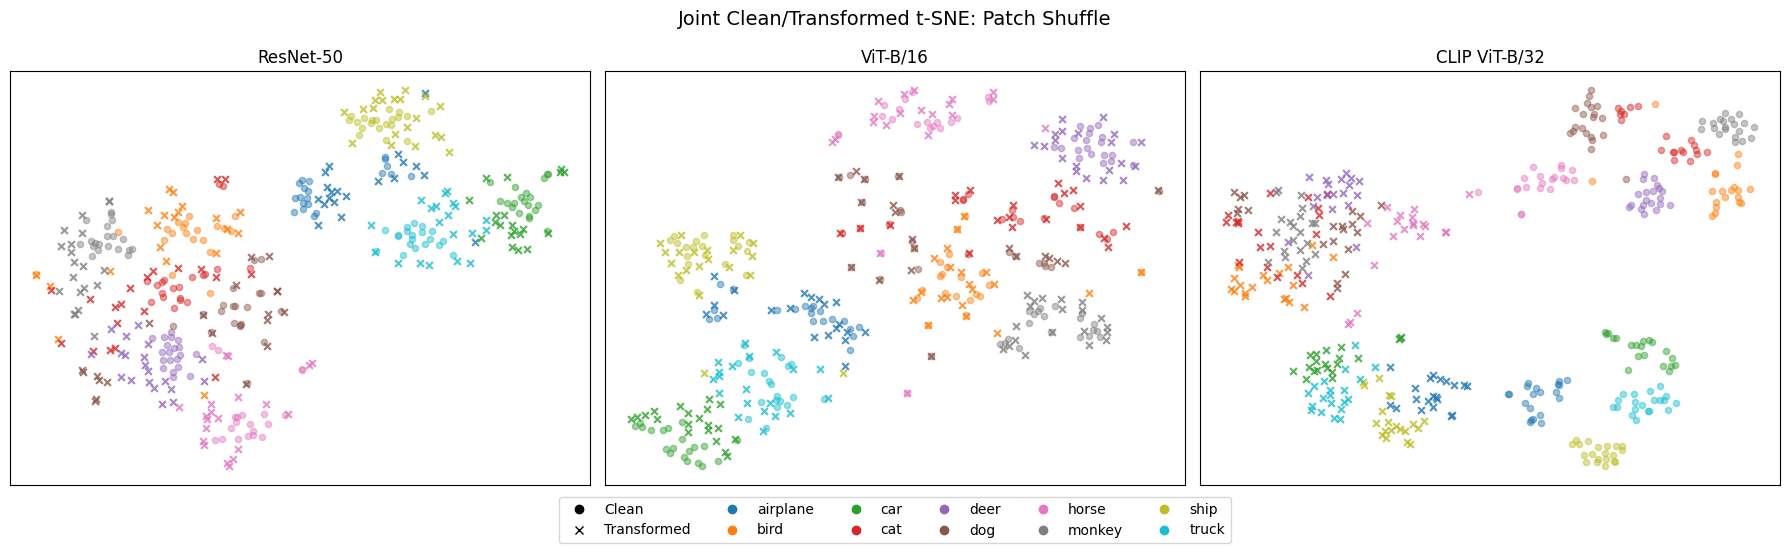

In [22]:
VISUALIZATION_INTERVENTIONS = {
    "grayscale": "Grayscale",
    "cue_conflict": "Cue Conflict",
    "translation_32px_right": (
        "Translation: 32 px Right"
    ),
    "patch_shuffle": "Patch Shuffle",
}

for intervention, display_name in (
    VISUALIZATION_INTERVENTIONS.items()
):
    print(
        "Creating projections for:",
        display_name,
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5),
    )

    for axis, model_name in zip(
        axes,
        MODEL_NAMES,
    ):
        (
            clean_features,
            transformed_features,
            labels,
        ) = get_visualization_pair(
            model_name,
            intervention,
        )

        projection = joint_tsne_projection(
            clean_features,
            transformed_features,
        )

        plot_projection(
            axis,
            projection,
            labels.numpy(),
            MODEL_DISPLAY_NAMES[
                model_name
            ],
        )

    clean_marker = plt.Line2D(
        [],
        [],
        color="black",
        marker="o",
        linestyle="None",
        label="Clean",
    )

    transformed_marker = plt.Line2D(
        [],
        [],
        color="black",
        marker="x",
        linestyle="None",
        label="Transformed",
    )

    class_handles = [
        plt.Line2D(
            [],
            [],
            color=CLASS_COLORS[class_id],
            marker="o",
            linestyle="None",
            label=CLASS_NAMES[class_id],
        )
        for class_id in range(NUM_CLASSES)
    ]

    fig.legend(
        handles=[
            clean_marker,
            transformed_marker,
            *class_handles,
        ],
        loc="lower center",
        ncol=6,
        bbox_to_anchor=(0.5, -0.10),
    )

    fig.suptitle(
        f"Joint Clean/Transformed t-SNE: "
        f"{display_name}",
        fontsize=14,
    )

    plt.tight_layout()

    file_name = (
        intervention
        .replace(":", "")
        .replace(" ", "_")
    )

    plt.savefig(
        FIGURES_DIR
        / f"tsne_{file_name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [23]:
color_patch_results = pd.read_csv(
    RESULTS_DIR / "color_patch_results.csv"
)

translation_results = pd.read_csv(
    RESULTS_DIR
    / "translation_average_results.csv"
)

display(
    color_patch_results.round(4)
)

display(
    translation_results[
        translation_results[
            "displacement"
        ] == 32
    ].round(4)
)

,model,evaluation,condition,accuracy,macro_f1,mean_max_confidence,accuracy_change,prediction_consistency
0,resnet50,linear_head,clean,0.976,0.9761,0.8978,0.000,1.000
1,resnet50,linear_head,grayscale,0.958,0.9578,0.9038,-0.018,0.964
2,resnet50,linear_head,hue_rotation_90,0.928,0.9278,0.8877,-0.048,0.940
3,resnet50,linear_head,patch_shuffle_4x4,0.876,0.8768,0.8711,-0.100,0.900
4,vit_b_16,linear_head,clean,0.974,0.9739,0.9590,0.000,1.000
5,vit_b_16,linear_head,grayscale,0.954,0.9539,0.9534,-0.020,0.950
6,vit_b_16,linear_head,hue_rotation_90,0.944,0.9440,0.9275,-0.030,0.944
7,vit_b_16,linear_head,patch_shuffle_4x4,0.906,0.9064,0.8844,-0.068,0.918
8,clip_vit_b_32,linear_head,clean,0.984,0.9840,0.3050,0.000,1.000
9,clip_vit_b_32,zero_shot,clean,0.980,0.9799,0.9548,0.000,1.000


,model,evaluation,displacement,accuracy,macro_f1,mean_max_confidence,accuracy_change,prediction_consistency
3,clip_vit_b_32,linear_head,32,0.9745,0.9745,0.2932,-0.0095,0.9875
7,clip_vit_b_32,zero_shot,32,0.9665,0.9664,0.9415,-0.0135,0.9825
11,resnet50,linear_head,32,0.9650,0.9651,0.8875,-0.0110,0.9865
15,vit_b_16,linear_head,32,0.9640,0.9640,0.9515,-0.0100,0.9760


In [24]:
comparison_rows = []

for row in color_patch_results.itertuples(
    index=False
):
    if row.condition not in [
        "grayscale",
        "patch_shuffle_4x4",
    ]:
        continue

    stability_condition = {
        "grayscale": "grayscale",
        "patch_shuffle_4x4": (
            "patch_shuffle"
        ),
    }[row.condition]

    matching_stability = (
        representation_stability_df[
            (
                representation_stability_df[
                    "model"
                ] == row.model
            )
            &
            (
                representation_stability_df[
                    "intervention"
                ] == stability_condition
            )
        ]
    )

    comparison_rows.append({
        "model": row.model,
        "evaluation": row.evaluation,
        "intervention": stability_condition,
        "prediction_consistency": (
            row.prediction_consistency
        ),
        "mean_cosine_stability": (
            matching_stability[
                "mean_cosine_stability"
            ].iloc[0]
        ),
        "accuracy_change": (
            row.accuracy_change
        ),
    })

translation_32_predictions = (
    translation_results[
        translation_results[
            "displacement"
        ] == 32
    ]
)

for row in (
    translation_32_predictions
    .itertuples(index=False)
):
    matching_stability = (
        representation_stability_df[
            (
                representation_stability_df[
                    "model"
                ] == row.model
            )
            &
            (
                representation_stability_df[
                    "intervention"
                ] == "translation_32px"
            )
        ]
    )

    comparison_rows.append({
        "model": row.model,
        "evaluation": row.evaluation,
        "intervention": "translation_32px",
        "prediction_consistency": (
            row.prediction_consistency
        ),
        "mean_cosine_stability": (
            matching_stability[
                "mean_cosine_stability"
            ].iloc[0]
        ),
        "accuracy_change": (
            row.accuracy_change
        ),
    })

prediction_representation_df = (
    pd.DataFrame(comparison_rows)
)

prediction_representation_df.to_csv(
    RESULTS_DIR
    / "prediction_representation_comparison.csv",
    index=False,
)

display(
    prediction_representation_df.round(4)
)

,model,evaluation,intervention,prediction_consistency,mean_cosine_stability,accuracy_change
0,resnet50,linear_head,grayscale,0.9640,0.7884,-0.0180
1,resnet50,linear_head,patch_shuffle,0.9000,0.7178,-0.1000
2,vit_b_16,linear_head,grayscale,0.9500,0.7393,-0.0200
3,vit_b_16,linear_head,patch_shuffle,0.9180,0.6534,-0.0680
4,clip_vit_b_32,linear_head,grayscale,0.9700,0.8983,-0.0220
5,clip_vit_b_32,zero_shot,grayscale,0.9720,0.8983,-0.0100
6,clip_vit_b_32,linear_head,patch_shuffle,0.8420,0.7290,-0.1500
7,clip_vit_b_32,zero_shot,patch_shuffle,0.8140,0.7290,-0.1640
8,clip_vit_b_32,linear_head,translation_32px,0.9875,0.9699,-0.0095
9,clip_vit_b_32,zero_shot,translation_32px,0.9825,0.9699,-0.0135


In [25]:
assert len(
    representation_stability_df
) == 12

assert representation_stability_df[
    "mean_cosine_stability"
].between(-1, 1).all()

zero_translation = (
    translation_stability_average_df[
        translation_stability_average_df[
            "displacement"
        ] == 0
    ]
)

assert np.allclose(
    zero_translation[
        "mean_cosine_stability"
    ],
    1.0,
    atol=1e-6,
)

assert len(
    visualization_indices
) == 200

assert len(
    np.unique(visualization_indices)
) == 200

print(
    "All representation-analysis checks passed."
)

All representation-analysis checks passed.
